In [ ]:
import numpy as np

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR   = "/content/drive/MyDrive/brain-tumor-classification"
MODELS_DIR = os.path.join(BASE_DIR, "models")

# Dataset paths — change TEST_PATH to use the held-out test set if available
TRAIN_PATH = os.path.join(BASE_DIR, "data/processed/Training")
TEST_PATH  = os.path.join(BASE_DIR, "data/processed/Testing")

# Use TEST_PATH for inference. If it doesn't exist, fall back to TRAIN_PATH.
INFER_PATH = TEST_PATH if os.path.isdir(TEST_PATH) else TRAIN_PATH
print(f'Running inference on: {INFER_PATH}')

IMG_SIZE   = 224
BATCH_SIZE = 32

# Output directory for ensemble results
ENSEMBLE_SAVE_DIR = os.path.join(MODELS_DIR, "Ensemble")
os.makedirs(ENSEMBLE_SAVE_DIR, exist_ok=True)

# ── Model file paths (best saved checkpoint from each notebook) ───────────────
MODEL_PATHS = {
    "VGG16": [
        os.path.join(MODELS_DIR, "VGG16_Enhanced", "best_model_phase2.h5"),
        os.path.join(MODELS_DIR, "VGG16_Enhanced", "vgg16_brain_tumor_final.keras"),  # fallback
        os.path.join(MODELS_DIR, "VGG16_Enhanced", "vgg16_brain_tumor_final.h5"),
        os.path.join(MODELS_DIR, "VGG16_Enhanced", "best_model_phase1.h5"),
    ],
    "ResNet50": [
        os.path.join(MODELS_DIR, "ResNet50_v2", "best_stage2.h5"),
        os.path.join(MODELS_DIR, "ResNet50_v2", "best_stage1.h5"),
    ],
    "EfficientNetB0": [
        os.path.join(MODELS_DIR, "effnet_best.keras"),
        os.path.join(MODELS_DIR, "EfficientNetB0", "effnet_best.keras"),
    ],
    "MobileNetV2": [
        os.path.join(MODELS_DIR, "mobilenetv2_best.keras"),
        os.path.join(MODELS_DIR, "MobileNetV2", "mobilenetv2_best.keras"),
    ],
}

print('\nModel path lookup:')
for name, paths in MODEL_PATHS.items():
    found = next((p for p in paths if os.path.exists(p)), None)
    status = f'✅ {found}' if found else '❌ NOT FOUND'
    print(f'  {name}: {status}')

Running inference on: /content/drive/MyDrive/brain-tumor-classification/data/processed/Testing

Model path lookup:
  VGG16: ✅ /content/drive/MyDrive/brain-tumor-classification/models/VGG16_Enhanced/best_model_phase2.h5
  ResNet50: ✅ /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5
  EfficientNetB0: ✅ /content/drive/MyDrive/brain-tumor-classification/models/effnet_best.keras
  MobileNetV2: ✅ /content/drive/MyDrive/brain-tumor-classification/models/mobilenetv2_best.keras


In [4]:
def load_dataset(base_path, img_size=IMG_SIZE):
    """
    Load all images from base_path/<class_name>/image.jpg structure.
    Returns uint8 RGB arrays, integer labels, and class names.
    """
    X, y, paths = [], [], []
    class_names = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])
    print(f'Classes found: {class_names}')

    for label, cls in enumerate(class_names):
        cls_folder = os.path.join(base_path, cls)
        files = sorted([
            f for f in os.listdir(cls_folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))
        ])
        print(f'  {cls}: {len(files)} images')

        for fname in files:
            img_path = os.path.join(cls_folder, fname)
            img = cv2.imread(img_path)
            if img is None:
                continue
            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_LANCZOS4)
            X.append(img)
            y.append(label)
            paths.append(img_path)

    return np.array(X, dtype=np.uint8), np.array(y), class_names, paths


X, y_true, CLASS_NAMES, img_paths = load_dataset(INFER_PATH)
NUM_CLASSES = len(CLASS_NAMES)
print(f'\nTotal images loaded : {len(X)}')
print(f'Image shape         : {X.shape[1:]}')
print(f'Classes             : {CLASS_NAMES}')

Classes found: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
  glioma_tumor: 100 images
  meningioma_tumor: 115 images
  no_tumor: 105 images
  pituitary_tumor: 74 images

Total images loaded : 394
Image shape         : (224, 224, 3)
Classes             : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [5]:
def preprocess_vgg16(imgs):
    """VGG16: zero-center by ImageNet mean (BGR order internally, but we pass RGB)"""
    from tensorflow.keras.applications.vgg16 import preprocess_input
    return preprocess_input(imgs.astype(np.float32))


def preprocess_resnet50(imgs):
    """ResNet50: zero-center by ImageNet mean"""
    return resnet_preprocess(imgs.astype(np.float32))


def preprocess_efficientnet(imgs):
    """
    EfficientNetB0 has an internal Rescaling layer.
    We pass raw uint8 images — no external rescaling.
    """
    return imgs.astype(np.float32)  # EfficientNet normalises internally


def preprocess_mobilenetv2(imgs):
    """MobileNetV2: map [0,255] → [-1, 1]"""
    return mobilenet_preprocess(imgs.astype(np.float32))


# Map model name → preprocessing function
PREPROCESS_FNS = {
    "VGG16"        : preprocess_vgg16,
    "ResNet50"     : preprocess_resnet50,
    "EfficientNetB0": preprocess_efficientnet,
    "MobileNetV2"  : preprocess_mobilenetv2,
}

print('Preprocessing functions registered.')

Preprocessing functions registered.


In [6]:
def load_best_model(name, candidate_paths):
    """Try each candidate path in order and return the first model that loads."""
    for path in candidate_paths:
        if os.path.exists(path):
            print(f'  Loading {name} from {path} ...', end=' ')
            try:
                model = load_model(path, compile=False)
                print(f'✅  ({model.count_params():,} params)')
                return model
            except Exception as e:
                print(f'⚠️  Failed: {e}')
    print(f'  ❌  {name}: no valid checkpoint found.')
    return None


loaded_models = {}
print('Loading models...\n')
for name, paths in MODEL_PATHS.items():
    model = load_best_model(name, paths)
    if model is not None:
        loaded_models[name] = model

print(f'\nSuccessfully loaded {len(loaded_models)} / {len(MODEL_PATHS)} models:')
for name in loaded_models:
    print(f'  ✅ {name}')

if not loaded_models:
    raise RuntimeError('No models were loaded. Check MODEL_PATHS and your Drive structure.')

Loading models...

  Loading VGG16 from /content/drive/MyDrive/brain-tumor-classification/models/VGG16_Enhanced/best_model_phase2.h5 ... ✅  (15,112,772 params)
  Loading ResNet50 from /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5 ... ✅  (26,350,212 params)
  Loading EfficientNetB0 from /content/drive/MyDrive/brain-tumor-classification/models/effnet_best.keras ... ✅  (5,496,231 params)
  Loading MobileNetV2 from /content/drive/MyDrive/brain-tumor-classification/models/mobilenetv2_best.keras ... ✅  (3,704,644 params)

Successfully loaded 4 / 4 models:
  ✅ VGG16
  ✅ ResNet50
  ✅ EfficientNetB0
  ✅ MobileNetV2


In [7]:
def predict_in_batches(model, X_raw, preprocess_fn, batch_size=BATCH_SIZE):
    """
    Run inference in batches and return softmax probability arrays.
    X_raw: uint8 numpy array (N, H, W, C)
    """
    all_probs = []
    n = len(X_raw)
    for start in range(0, n, batch_size):
        batch = X_raw[start : start + batch_size]
        batch_processed = preprocess_fn(batch)
        probs = model.predict(batch_processed, verbose=0)
        all_probs.append(probs)
    return np.vstack(all_probs)   # (N, num_classes)


print('Running per-model inference...\n')
model_probs = {}   # name → (N, num_classes) probability matrix

for name, model in loaded_models.items():
    print(f'  Predicting with {name}...', end=' ')
    preprocess_fn = PREPROCESS_FNS[name]
    probs = predict_in_batches(model, X, preprocess_fn)
    model_probs[name] = probs
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(y_true, preds)
    print(f'done.  Accuracy: {acc*100:.2f}%')

print('\nAll individual predictions complete.')

Running per-model inference...

  Predicting with VGG16... done.  Accuracy: 45.69%
  Predicting with ResNet50... done.  Accuracy: 79.19%
  Predicting with EfficientNetB0... done.  Accuracy: 75.38%
  Predicting with MobileNetV2... done.  Accuracy: 75.89%

All individual predictions complete.


In [8]:
# ── Equal-weight soft voting ───────────────────────────────────────────────────
prob_stack   = np.stack(list(model_probs.values()), axis=0)  # (M, N, C)
ensemble_avg = np.mean(prob_stack, axis=0)                   # (N, C)
ensemble_pred = np.argmax(ensemble_avg, axis=1)              # (N,)

# ── Per-model accuracy for reference ──────────────────────────────────────────
print('Per-Model Accuracy vs Ensemble')
print('=' * 45)
for name, probs in model_probs.items():
    preds = np.argmax(probs, axis=1)
    acc   = accuracy_score(y_true, preds)
    print(f'  {name:<20}: {acc*100:.2f}%')

ensemble_acc = accuracy_score(y_true, ensemble_pred)
print(f'  {"Ensemble (soft)":<20}: {ensemble_acc*100:.2f}%')
print('=' * 45)

Per-Model Accuracy vs Ensemble
  VGG16               : 45.69%
  ResNet50            : 79.19%
  EfficientNetB0      : 75.38%
  MobileNetV2         : 75.89%
  Ensemble (soft)     : 77.16%


In [9]:
# Weight each model by its individual accuracy on this dataset
weights = []
for name, probs in model_probs.items():
    preds = np.argmax(probs, axis=1)
    acc   = accuracy_score(y_true, preds)
    weights.append(acc)

weights = np.array(weights)
weights = weights / weights.sum()   # normalise to sum=1

print('Ensemble weights based on individual accuracy:')
for name, w in zip(model_probs.keys(), weights):
    print(f'  {name:<20}: {w:.4f}')

# Weighted average
weighted_avg  = np.tensordot(weights, prob_stack, axes=[[0], [0]])  # (N, C)
weighted_pred = np.argmax(weighted_avg, axis=1)
weighted_acc  = accuracy_score(y_true, weighted_pred)

print(f'\nWeighted Ensemble Accuracy: {weighted_acc*100:.2f}%')
print(f'Equal   Ensemble Accuracy : {ensemble_acc*100:.2f}%')

# Use the better ensemble
if weighted_acc >= ensemble_acc:
    BEST_PROBS  = weighted_avg
    BEST_PREDS  = weighted_pred
    BEST_METHOD = 'Weighted Soft Voting'
else:
    BEST_PROBS  = ensemble_avg
    BEST_PREDS  = ensemble_pred
    BEST_METHOD = 'Equal Soft Voting'

print(f'\nBest ensemble method selected: {BEST_METHOD}  ({max(ensemble_acc, weighted_acc)*100:.2f}%)')

Ensemble weights based on individual accuracy:
  VGG16               : 0.1654
  ResNet50            : 0.2868
  EfficientNetB0      : 0.2730
  MobileNetV2         : 0.2748

Weighted Ensemble Accuracy: 78.17%
Equal   Ensemble Accuracy : 77.16%

Best ensemble method selected: Weighted Soft Voting  (78.17%)


In [10]:
print(f'\n{BEST_METHOD} — Classification Report')
print('=' * 60)
print(classification_report(y_true, BEST_PREDS, target_names=CLASS_NAMES, digits=4))

overall_f1  = f1_score(y_true, BEST_PREDS, average='weighted')
overall_prec = precision_score(y_true, BEST_PREDS, average='weighted')
overall_rec  = recall_score(y_true, BEST_PREDS, average='weighted')

print(f'Overall Accuracy  : {accuracy_score(y_true, BEST_PREDS)*100:.4f}%')
print(f'Weighted Precision: {overall_prec*100:.4f}%')
print(f'Weighted Recall   : {overall_rec*100:.4f}%')
print(f'Weighted F1-Score : {overall_f1*100:.4f}%')


Weighted Soft Voting — Classification Report
                  precision    recall  f1-score   support

    glioma_tumor     0.9355    0.2900    0.4427       100
meningioma_tumor     0.7075    0.9043    0.7939       115
        no_tumor     0.7343    1.0000    0.8468       105
 pituitary_tumor     0.9589    0.9459    0.9524        74

        accuracy                         0.7817       394
       macro avg     0.8340    0.7851    0.7589       394
    weighted avg     0.8197    0.7817    0.7486       394

Overall Accuracy  : 78.1726%
Weighted Precision: 81.9710%
Weighted Recall   : 78.1726%
Weighted F1-Score : 74.8629%


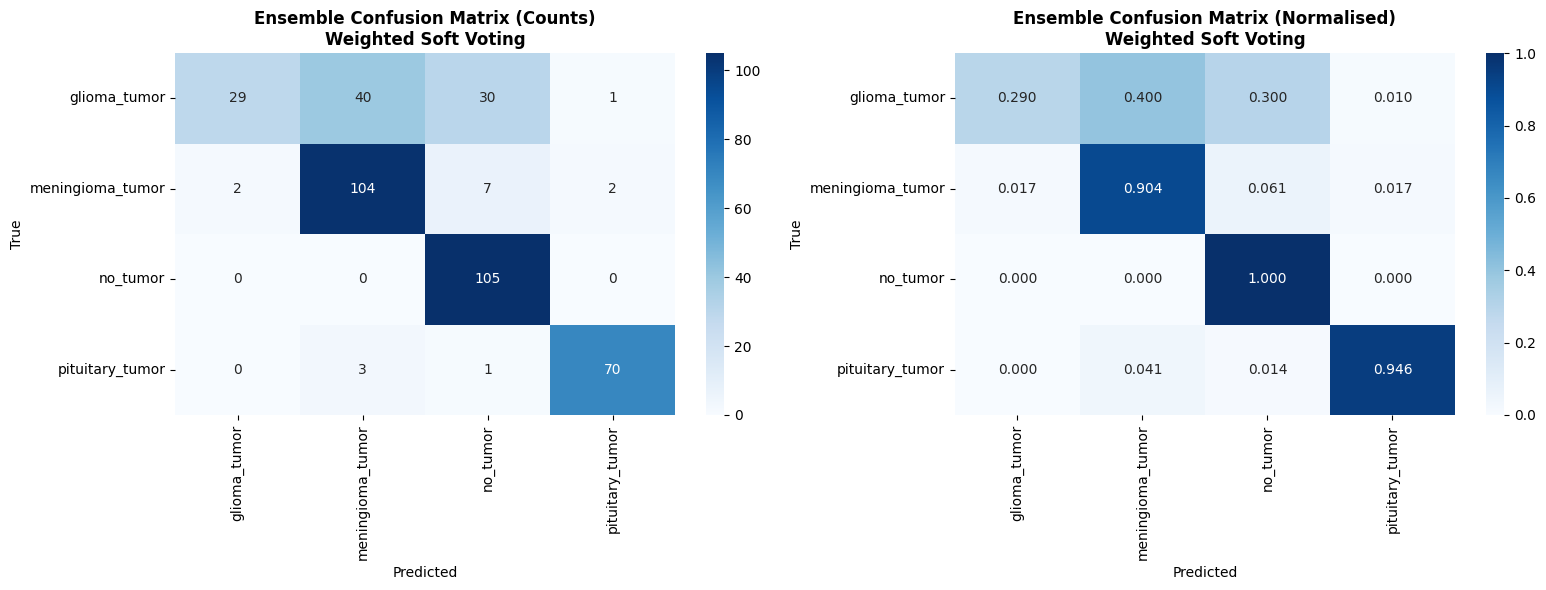

Saved to /content/drive/MyDrive/brain-tumor-classification/models/Ensemble/ensemble_confusion_matrix.png


In [11]:
cm = confusion_matrix(y_true, BEST_PREDS)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title(f'Ensemble Confusion Matrix (Counts)\n{BEST_METHOD}', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Normalised
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title(f'Ensemble Confusion Matrix (Normalised)\n{BEST_METHOD}', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
save_path = os.path.join(ENSEMBLE_SAVE_DIR, 'ensemble_confusion_matrix.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {save_path}')

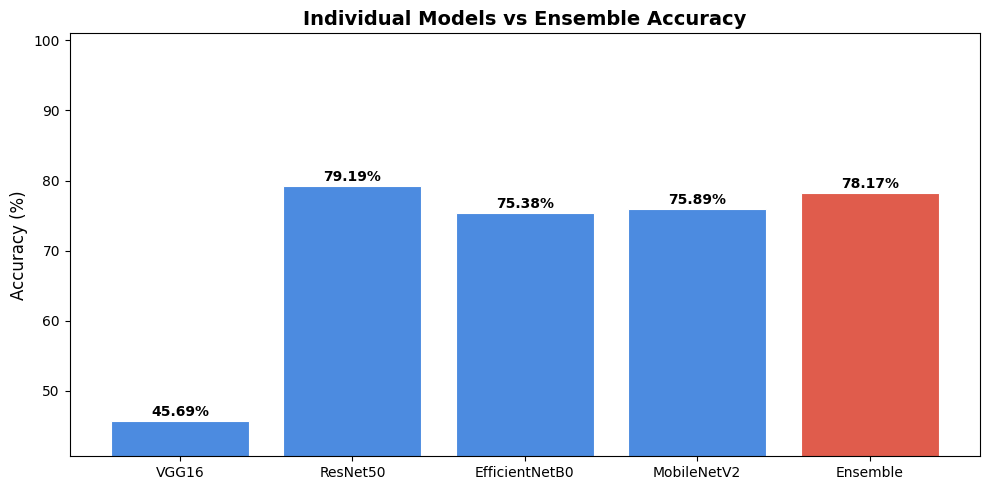

Saved to /content/drive/MyDrive/brain-tumor-classification/models/Ensemble/model_accuracy_comparison.png


In [12]:
names, accs = [], []
for name, probs in model_probs.items():
    preds = np.argmax(probs, axis=1)
    names.append(name)
    accs.append(accuracy_score(y_true, preds) * 100)
names.append('Ensemble')
accs.append(accuracy_score(y_true, BEST_PREDS) * 100)

colors = ['#4C8BE0'] * (len(names) - 1) + ['#E05C4C']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, accs, color=colors, edgecolor='white', linewidth=0.8)
ax.set_ylim(max(0, min(accs) - 5), 101)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Individual Models vs Ensemble Accuracy', fontsize=14, fontweight='bold')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
save_path = os.path.join(ENSEMBLE_SAVE_DIR, 'model_accuracy_comparison.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {save_path}')

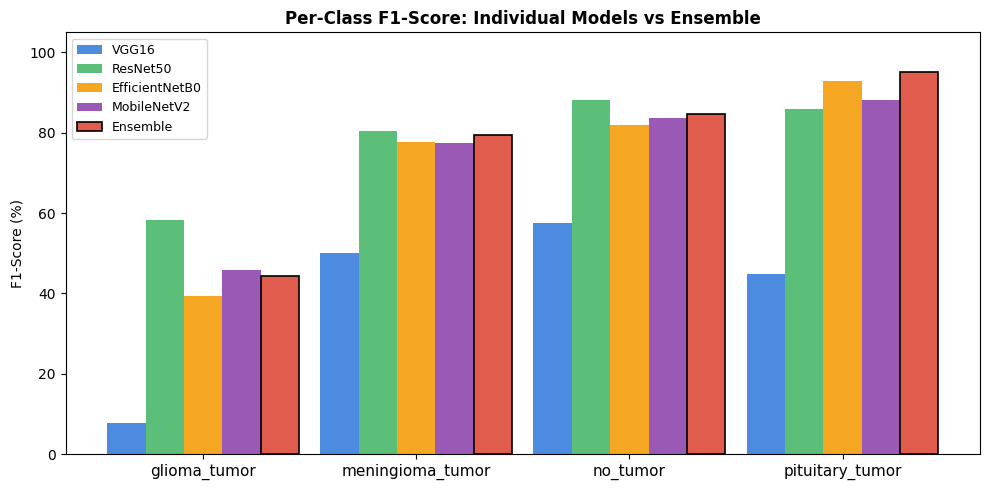

Saved to /content/drive/MyDrive/brain-tumor-classification/models/Ensemble/per_class_f1_comparison.png


In [13]:
from sklearn.metrics import f1_score as f1

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(NUM_CLASSES)
width = 0.18
model_list = list(model_probs.keys())
palette = ['#4C8BE0', '#5BBF7A', '#F5A623', '#9B59B6', '#E05C4C']

for i, name in enumerate(model_list):
    preds = np.argmax(model_probs[name], axis=1)
    f1_per_class = f1(y_true, preds, average=None, labels=range(NUM_CLASSES))
    ax.bar(x + i * width, f1_per_class * 100, width, label=name, color=palette[i % len(palette)])

# Ensemble bar
ens_f1_per_class = f1(y_true, BEST_PREDS, average=None, labels=range(NUM_CLASSES))
ax.bar(x + len(model_list) * width, ens_f1_per_class * 100, width,
       label='Ensemble', color=palette[-1], edgecolor='black', linewidth=1.2)

ax.set_xticks(x + width * (len(model_list) / 2))
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel('F1-Score (%)')
ax.set_title('Per-Class F1-Score: Individual Models vs Ensemble', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 105)
plt.tight_layout()
save_path = os.path.join(ENSEMBLE_SAVE_DIR, 'per_class_f1_comparison.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {save_path}')

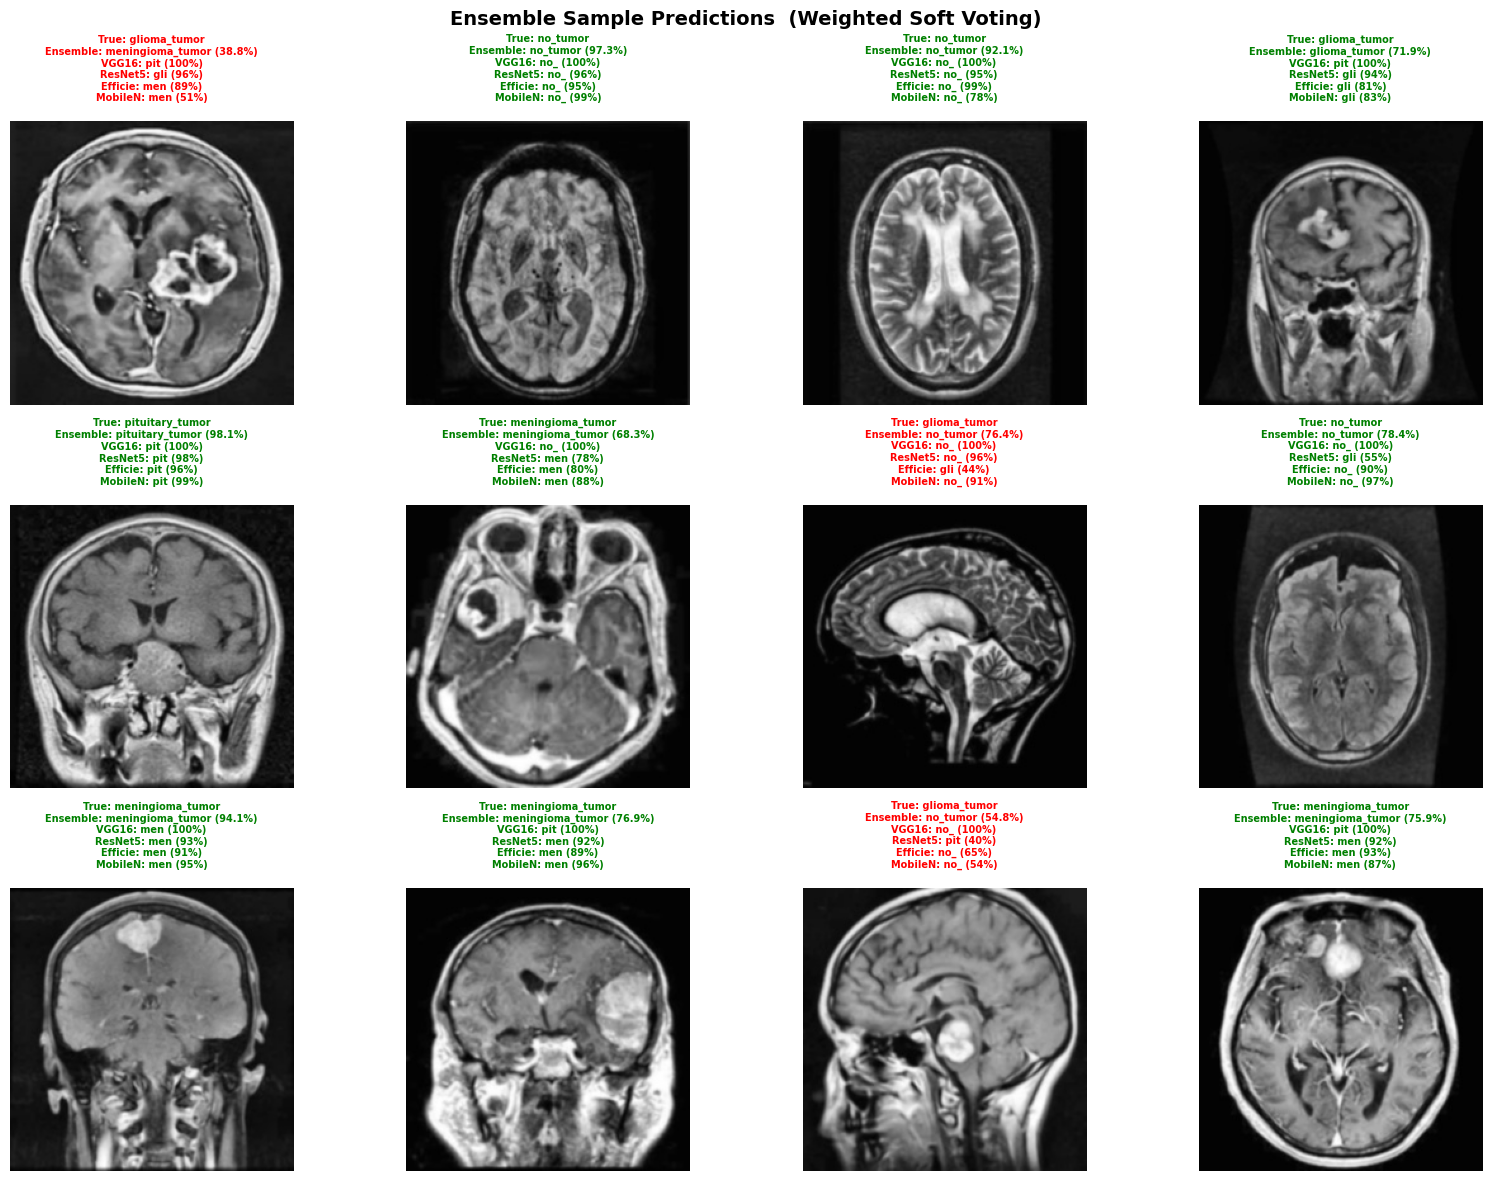

Saved to /content/drive/MyDrive/brain-tumor-classification/models/Ensemble/sample_ensemble_predictions.png


In [14]:
np.random.seed(42)
num_samples = min(12, len(X))
rand_idx = np.random.choice(len(X), num_samples, replace=False)

n_cols = 4
n_rows = (num_samples + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for plot_i, i in enumerate(rand_idx):
    ax = axes[plot_i]
    ax.imshow(X[i])
    ax.axis('off')

    true_lbl  = CLASS_NAMES[y_true[i]]
    pred_lbl  = CLASS_NAMES[BEST_PREDS[i]]
    confidence= BEST_PROBS[i][BEST_PREDS[i]]

    # Show per-model predictions below
    per_model_info = ''
    for name, probs in model_probs.items():
        p_idx = np.argmax(probs[i])
        per_model_info += f'{name[:7]}: {CLASS_NAMES[p_idx][:3]} ({probs[i][p_idx]:.0%})\n'

    color = 'green' if pred_lbl == true_lbl else 'red'
    ax.set_title(
        f'True: {true_lbl}\nEnsemble: {pred_lbl} ({confidence:.1%})\n{per_model_info}',
        fontsize=7, color=color, fontweight='bold'
    )

for ax in axes[num_samples:]:
    ax.axis('off')

plt.suptitle(f'Ensemble Sample Predictions  ({BEST_METHOD})', fontsize=14, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(ENSEMBLE_SAVE_DIR, 'sample_ensemble_predictions.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {save_path}')

In [15]:
print('\n' + '=' * 60)
print('ENSEMBLE FINAL SUMMARY')
print('=' * 60)
print(f'Dataset         : {INFER_PATH}')
print(f'Total images    : {len(X)}')
print(f'Classes         : {CLASS_NAMES}')
print(f'Models loaded   : {list(loaded_models.keys())}')
print(f'Ensemble method : {BEST_METHOD}')
print('-' * 60)
print('Individual Model Accuracies:')
for name, probs in model_probs.items():
    preds = np.argmax(probs, axis=1)
    print(f'  {name:<20}: {accuracy_score(y_true, preds)*100:.2f}%')
print('-' * 60)
print(f'  {"Ensemble":<20}: {accuracy_score(y_true, BEST_PREDS)*100:.2f}%')
print(f'  Weighted F1   : {f1_score(y_true, BEST_PREDS, average="weighted")*100:.4f}%')
print('=' * 60)
print(f'Results saved to: {ENSEMBLE_SAVE_DIR}')


ENSEMBLE FINAL SUMMARY
Dataset         : /content/drive/MyDrive/brain-tumor-classification/data/processed/Testing
Total images    : 394
Classes         : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Models loaded   : ['VGG16', 'ResNet50', 'EfficientNetB0', 'MobileNetV2']
Ensemble method : Weighted Soft Voting
------------------------------------------------------------
Individual Model Accuracies:
  VGG16               : 45.69%
  ResNet50            : 79.19%
  EfficientNetB0      : 75.38%
  MobileNetV2         : 75.89%
------------------------------------------------------------
  Ensemble            : 78.17%
  Weighted F1   : 74.8629%
Results saved to: /content/drive/MyDrive/brain-tumor-classification/models/Ensemble
